In [1]:
#| default_exp species


In [2]:
#| export

import numpy as np
from pathlib import Path
from dataclasses import dataclass
from IPython.display import Image
from typing import List



# Step 5: Identify the species

![Step 5 diagram](https://raw.githubusercontent.com/jaewilson07/bird-watcher/main/docs/diagrams/05-step.png)

**Goal:** given a photo, tell me what *species* the bird is.

Detection said *'there's a bird here'*. Now we want *'it's a Northern Cardinal'*. We use a separate model — an image classifier fine-tuned on hundreds of bird species.

The function `name_bird_in_image` lives in `bird_watcher/name_bird.py`.

## Step 5.0 — Setup

In [3]:
from dotenv import load_dotenv
import os
assert load_dotenv(), "Failed to load .env file"

BIRD_MODEL = os.environ.get('BIRD_MODEL_QUALITY')

HF_TOKEN = os.environ.get("HF_TOKEN", "")
HF_HOME = os.environ.get('HF_HOME', '../data/models/')

SAMPLE_IMAGE_PATH = '../data/samples/dog_bird.jpg'

## Step 5.1 — Detect, then crop

our previous ImageDetection work exclusively detects the class of animal (bird, or dog) it does not answer species, unfortunately each class of animal will have a unique model for classifying it.   Our job will be to standardize so that the result is always in the same format.  --  A great use for classes!

think of a game.  You could have a mage and a ranger doing damage with a bow or a wand.  but if i need a DamageCalculator to calculate damage, we don't care what weapon did the damage i just need a consistent number at the end.  I might have different functions for calculating wand damage vs bow damage (because wands don't crit and maybe bows do-- and maybe bows scale with Agility vs wands that scale with Int.  Doesn't matter the inputs must be the same (my character and their weapon) and the output should be the same, damage calculation

In [4]:
from bird_watcher.detect import ImageDetection, YoloModelEnum
from ultralytics import YOLO


model = YOLO(YoloModelEnum.QUALITY.value)

img_w_detect = ImageDetection.from_path(img_path = SAMPLE_IMAGE_PATH, model = model)

only_birds = [detection for detection in img_w_detect.detections if detection.label == "bird"]

print(f"There were {len(img_w_detect.detections)} detections of which {len(only_birds)} were bird detections.")

There were 2 detections of which 1 were bird detections.


## Step 5.2 — Run the species classifier

We can use the SpeciesGuess as a base model for Guessing the species of an image.  There will be different variations of HOW i calcualte the species based on label (bird or dog), so maybe I should have a DogGuess and a BirdGuess variant of Species Guess (this is called subclassing)


Why are we doing this?  ultralytics 'YOLO' model can only label objects.  To get the species, we need a model that specializes in identifying bird species

In [5]:
#| export

@dataclass
class SpeciesGuess:
    species: str
    confidence: float

    def print(self): # the standardized output
        return f"Species: {self.species}, Confidence: {self.confidence:.2f}"

@dataclass
class ImageClassifier:
    img : Image
    guesses : List[SpeciesGuess] = None

    @property
    def species(self):
        if self.guesses is None or len(self.guesses) == 0:
            self.classify()
        return self.guesses[0].species
    
    @property
    def confidence(self):
        if self.guesses is None or len(self.guesses) == 0:
            self.classify()
        return self.guesses[0].confidence

    @property
    def print(self):
        if self.guesses is None or len(self.guesses) == 0:
            self.classify()

        if not self.guesses:
            raise ValueError("No guesses available. The classify method did not return any results.")

        return f"This is a {self.guesses[0].species} with a confidence of {self.guesses[0].confidence:.2f}"
    
    def __post_init__(self):
        self.classify()

        
    def classify(self):
        raise NotImplementedError("Subclasses should implement this method.")

In [6]:
from transformers import pipeline


bird_classifier = pipeline(
    task="image-classification",
    model="dennisjooo/Birds-Classifier-EfficientNetB2",
)

/home/jaewilson07/GitHub/bird-watcher/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 508/508 [00:00<00:00, 6326.04it/s]


In [7]:
#| export
@dataclass
class BirdClassifier(ImageClassifier):
    
    def classify(self, debug_prn: bool = False):

        results = bird_classifier(self.img, top_k=3)
        
        guesses = [SpeciesGuess(species=res['label'], confidence=res['score']) for res in results]

        if debug_prn:
            for guess in guesses:
                print(guess.print())
            
        self.guesses = guesses
        return guesses[0]

This is a FAN TAILED WIDOW with a confidence of 0.31


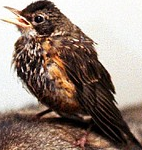

In [8]:
for bird in only_birds:
    guess = BirdClassifier(bird.print_cropped_image)

    print(guess.print)

    display(bird.print_cropped_image)

In [9]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="dimeshanthoney/dog-breed-classifier",
    filename="Image_classify.keras",
    cache_dir=HF_HOME,
    token=HF_TOKEN,
)

In [10]:
import tensorflow as tf


dog_model = tf.keras.models.load_model(model_path)

dog_class_names = [
    'afghan_hound', 'african_hunting_dog', 'airedale', 'basenji', 'basset', 'beagle',
    'bedlington_terrier', 'bernese_mountain_dog', 'black-and-tan_coonhound',
    'blenheim_spaniel', 'bloodhound', 'bluetick', 'border_collie', 'border_terrier',
    'borzoi', 'boston_bull', 'bouvier_des_flandres', 'brabancon_griffon', 'bull_mastiff',
    'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chow', 'clumber', 'cocker_spaniel',
    'collie', 'curly-coated_retriever', 'dhole', 'dingo', 'doberman', 'english_foxhound',
    'english_setter', 'entlebucher', 'flat-coated_retriever', 'german_shepherd',
    'german_short-haired_pointer', 'golden_retriever', 'gordon_setter', 'great_dane',
    'great_pyrenees', 'groenendael', 'ibizan_hound', 'irish_setter', 'irish_terrier',
    'irish_water_spaniel', 'irish_wolfhound', 'japanese_spaniel', 'keeshond',
    'kerry_blue_terrier', 'komondor', 'kuvasz', 'labrador_retriever', 'leonberg', 'lhasa',
    'malamute', 'malinois', 'maltese_dog', 'mexican_hairless', 'miniature_pinscher',
    'miniature_schnauzer', 'newfoundland', 'norfolk_terrier', 'norwegian_elkhound',
    'norwich_terrier', 'old_english_sheepdog', 'otterhound', 'papillon', 'pekinese',
    'pembroke', 'pomeranian', 'pug', 'redbone', 'rhodesian_ridgeback', 'rottweiler',
    'saint_bernard', 'saluki', 'samoyed', 'schipperke', 'scotch_terrier',
    'scottish_deerhound', 'sealyham_terrier', 'shetland_sheepdog', 'standard_poodle',
    'standard_schnauzer', 'sussex_spaniel', 'tibetan_mastiff', 'tibetan_terrier',
    'toy_terrier', 'vizsla', 'weimaraner', 'whippet', 'wire-haired_fox_terrier',
    'yorkshire_terrier'
]

I0000 00:00:1783533286.200851  356954 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [11]:
#| export

@dataclass
class DogClassifier(ImageClassifier):
    """Predict dog breed probabilities for a cropped dog image.

    Args:
        img: a PIL image containing one dog.
        top_k: how many predictions to return.
        verbose: if True, print the top predictions.

    Returns:
        A list of predictions sorted by confidence.
    """

    def classify(self, top_k: int = 3, debug_prn: bool = False):

        resized_img = self.img.convert("RGB").resize((224, 224))
        img_array = tf.keras.utils.img_to_array(resized_img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = dog_model.predict(img_array, verbose=0)[0]
        top_indices = np.argsort(predictions)[::-1][:top_k]

        self.guesses = [SpeciesGuess(species=dog_class_names[index], confidence=float(predictions[index])) for index in top_indices]

        if debug_prn:
            for guess in self.guesses:
                print(guess.print())
        
        return self.guesses[0]



This is a border_terrier with a confidence of 0.51


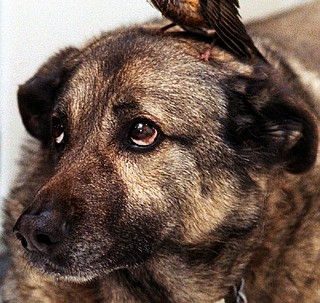

In [12]:
only_dogs = [detection for detection in img_w_detect.detections if detection.label == "dog"]

for dog in only_dogs:
    
    guess = DogClassifier(dog.print_cropped_image)

    print(guess.print)

    display(dog.print_cropped_image)


Instead of having stand alone functions that handle species classification, it would be clever to add this function to the ImageDetected class

In [13]:
#| export
from enum import Enum
from fastcore.basics import patch_to
from bird_watcher.detect import ImageDetected, ImageDetection

class ImageClassifierEnum(Enum):
    BIRD = BirdClassifier
    DOG = DogClassifier


@patch_to(ImageDetected)
def __post_init__(self):
    classifier_enum = ImageClassifierEnum.__members__.get(self.label.upper())
    if classifier_enum is None:
        self.Classifier = None
        return
    self.Classifier = classifier_enum.value(self.print_cropped_image)

In [14]:
ImageClassifierEnum.__members__.get('bird'.upper()).value

__main__.BirdClassifier

In [15]:
img_w_detect = ImageDetection.from_path(
    img_path=SAMPLE_IMAGE_PATH,
    model=model,
    confidence=0.7,
    debug_prn=False,
 )

for detection in img_w_detect.detections:
    print(detection.label)

    if detection.Classifier is None:
        print(f"No classifier configured for label: {detection.label}")
        continue

    print(detection.Classifier.print)

bird
This is a FAN TAILED WIDOW with a confidence of 0.31
dog
This is a border_terrier with a confidence of 0.51


## What's next

**Step 6:** open [06-persist.ipynb](06-persist.ipynb) — we'll save every sighting to a SQLite database.